# LING 498 Hackathon — Prompt 10

## Onset clusters (phonotactics proxy)

**Category:** Phonology

**Question:** Are onset clusters Zipf-like? Do rare clusters align with markedness/phonotactic restrictions?

- **Data:** CMUdict pronunciations (strip stress digits).
- **Items to Count:** Phones from start up to first vowel; join with "-" (e.g., S-T-R).

**Steps**
- Define vowel set (provided in notebook scaffold).
- For each pronunciation, collect initial phones until first vowel.
- Join as a cluster type; count clusters; run Zipf report/plot.
- Interpret: common vs rare clusters; lexicalization vs phonotactic constraints.

**Deliverable:** Top-15 onsets + 2 notes on markedness + 1 limitation of the vowel-set heuristic.

In [47]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

In [ ]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Zipf Plot"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked)) + 1))
    freqs = [ranked[i - 1][1] for i in ranks]
    plt.figure(figsize=(7, 5))
    plt.loglog(ranks, freqs, marker='o', linestyle='-', markersize=4)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [49]:
# load the phonetic dictionary (scaffold)
cmu_dict = cmudict.dict()

In [ ]:
# inspect data
print("Number of word entries:", len(cmu_dict))
print()

sample_words = list(cmu_dict.keys())[:10]

for word in sample_words:
    pronunciations = cmu_dict[word]
    print(word, "→", pronunciations)

Number of word entries: 123455

a → [['AH0'], ['EY1']]
a. → [['EY1']]
a42128 → [['EY1', 'F', 'AO1', 'R', 'T', 'UW1', 'W', 'AH1', 'N', 'T', 'UW1', 'EY1', 'T']]
aaa → [['T', 'R', 'IH2', 'P', 'AH0', 'L', 'EY1']]
aaberg → [['AA1', 'B', 'ER0', 'G']]
aachen → [['AA1', 'K', 'AH0', 'N']]
aachener → [['AA1', 'K', 'AH0', 'N', 'ER0']]
aaker → [['AA1', 'K', 'ER0']]
aalseth → [['AA1', 'L', 'S', 'EH0', 'TH']]
aamodt → [['AA1', 'M', 'AH0', 'T']]


In [ ]:
# define vowels
vowels = [
    "AA", "AE", "AH", "AO", "AW", "AY",
    "EH", "ER", "EY",
    "IH", "IY",
    "OW", "OY",
    "UH", "UW"
]

In [54]:
# strip stress digits
def strip_stress(phone):
    phone_without_stress = re.sub(r"\d", "", phone)
    return phone_without_stress

# testing function
print(strip_stress("AE1"))
print(strip_stress("AH0"))
print(strip_stress("IY2"))
print(strip_stress("K"))

AE
AH
IY
K


In [61]:
# extract onset cluster
def get_onset_cluster(phones):
    onset_phones = []

    for phone in phones:
        clean_phone = strip_stress(phone)

        if clean_phone in vowels:
            break

        onset_phones.append(clean_phone)

    cluster_type = "-".join(onset_phones)

    return cluster_type

In [ ]:
test_onsets = [
    ["P", "L", "EY1"],
    ["S", "T", "R", "IY1", "T"],
    ["K", "AE1", "T"],
    ["AE1", "P", "AH0", "L"]
]

for phones in test_onsets:
    cluster_type = get_onset_cluster(phones)
    print(phones, "→", cluster_type)
    
# if there are no onset clusters = "" or empty

['P', 'L', 'EY1'] → P-L
['S', 'T', 'R', 'IY1', 'T'] → S-T-R
['K', 'AE1', 'T'] → K
['AE1', 'P', 'AH0', 'L'] → 


In [71]:
cluster_types = []

for word in cmu_dict:
    pronunciations = cmu_dict[word]

    for phones in pronunciations:
        cluster_type = get_onset_cluster(phones)
# if empty
        if cluster_type != "": 
            cluster_types.append(cluster_type)


=== CMUdict Onset Clusters ===
Types: 154 | Tokens: 113614
Top items:
 1. K                                        9837
 2. M                                        9294
 3. R                                        7467
 4. B                                        7177
 5. D                                        7173
 6. S                                        6919
 7. HH                                       6134
 8. L                                        5455
 9. P                                        5435
10. F                                        3923
11. W                                        3771
12. T                                        3524
13. N                                        3223
14. G                                        3173
15. V                                        2376

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.529
 f1/(3*f3) = 0.439
 f1/(4*f4) = 0.343
 f1/(5*f5) = 0.274


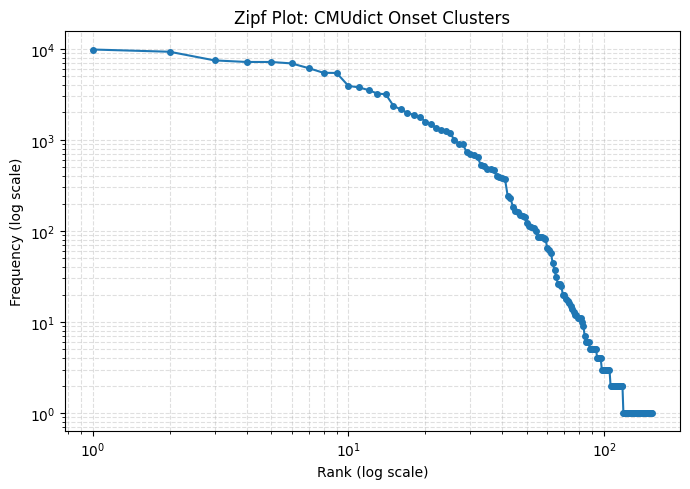

In [ ]:
ranked_clusters = zipf_prep(cluster_types)
zipf_quick_report(cluster_types, title="CMUdict Onset Clusters")
zipf_plot(ranked_clusters, title="Zipf Plot: CMUdict Onset Clusters")